<a href="https://colab.research.google.com/github/joaolucasgs/AV_S206LAB/blob/main/C318_2026_1_Atividade_02_191.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 02: Análise Exploratória de Dados (EDA)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_02_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: data de criação, domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.
- #### <font color='cyan'>Becker, B. & Kohavi, R. (1996). Adult Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.</font>

## <font color='green'>Preparação</font>

### <font color='cyan'>Dataset: Becker, B. & Kohavi, R. (1996). Adult Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.</font>

In [1]:
!pip install pandas ucimlrepo

In [2]:
import pandas as pd

from pprint import pprint
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

In [3]:
pprint(adult.metadata)

{'abstract': 'Predict whether annual income of an individual exceeds $50K/yr '
             'based on census data. Also known as "Census Income" dataset. ',
 'additional_info': {'citation': None,
                     'funded_by': None,
                     'instances_represent': None,
                     'preprocessing_description': None,
                     'purpose': None,
                     'recommended_data_splits': None,
                     'sensitive_data': None,
                     'summary': 'Extraction was done by Barry Becker from the '
                                '1994 Census database.  A set of reasonably '
                                'clean records was extracted using the '
                                'following conditions: ((AAGE>16) && (AGI>100) '
                                '&& (AFNLWGT>1)&& (HRSWK>0))\n'
                                '\n'
                                'Prediction task is to determine whether a '
                               

In [4]:
adult.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,N/A,None,no
1,workclass,Feature,Categorical,Income,"Private, Self-emp-not-inc, Self-emp-inc, Feder...",None,yes
2,fnlwgt,Feature,Integer,None,None,None,no
3,education,Feature,Categorical,Education Level,"Bachelors, Some-college, 11th, HS-grad, Prof-...",None,no
4,education-num,Feature,Integer,Education Level,None,None,no
5,marital-status,Feature,Categorical,Other,"Married-civ-spouse, Divorced, Never-married, S...",None,no
6,occupation,Feature,Categorical,Other,"Tech-support, Craft-repair, Other-service, Sal...",None,yes
7,relationship,Feature,Categorical,Other,"Wife, Own-child, Husband, Not-in-family, Other...",None,no
8,race,Feature,Categorical,Race,"White, Asian-Pac-Islander, Amer-Indian-Eskimo,...",None,no
9,sex,Feature,Binary,Sex,"Female, Male.",None,no


In [5]:
X = adult.data.features
y = adult.data.targets

df = pd.concat([X, y], axis='columns')

df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


## <font color='green'>**2.1 Conjuntos de Dados**</font>

### <font color='cyan'>Q1: Exiba 10 amostras aleatórias do conjunto de dados.</font>

In [6]:
df.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
13206,36,Local-gov,95855,Masters,14,Married-civ-spouse,Prof-specialty,Wife,White,Female,0,0,60,United-States,>50K
19987,45,State-gov,187581,Assoc-voc,11,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,<=50K
43421,55,Private,128045,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,United-States,<=50K.
32757,44,Private,299197,Some-college,10,Never-married,Transport-moving,Not-in-family,White,Male,0,0,45,United-States,<=50K.
21324,20,State-gov,432052,Some-college,10,Never-married,Handlers-cleaners,Not-in-family,White,Male,0,0,15,United-States,<=50K
14069,24,Private,225515,Bachelors,13,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,40,United-States,<=50K
37963,50,Local-gov,237868,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K.
10255,74,Self-emp-not-inc,104001,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,>50K
26655,38,Private,52738,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
6193,39,State-gov,189385,Some-college,10,Separated,Exec-managerial,Unmarried,Black,Female,0,0,30,United-States,<=50K


### <font color='cyan'>Q2: Quantas amostras o conjunto de dados possui?</font>

> Adicionar aspas



In [8]:
print(f"O conjunto de dados possui {df.shape[0]} amostras.")

O conjunto de dados possui 48842 amostras.


### <font color='cyan'>Q3: Quantas características o conjunto de dados possui?</font>

In [9]:
print(f"O conjunto de dados possui {df.shape[1]} características.")

O conjunto de dados possui 15 características.


### <font color='cyan'>Q4: O conjunto de dados possui características numéricas? Se sim, escreva seu(s) nome(s) e classifique-a(s) como contínua(s) e/ou discreta(s).</font>
- #### <font color='cyan'>Observação: considere que uma caraterística numérica é discreta se possui menos que 50 valores únicos.</font>

In [10]:
numeric_features = []
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        unique_count = df[col].nunique()
        feature_type = 'discreta' if unique_count < 50 else 'contínua'
        numeric_features.append(f"{col} ({feature_type})")

if numeric_features:
    print("O conjunto de dados possui as seguintes características numéricas:")
    for feature in numeric_features:
        print(f"- {feature}")
else:
    print("O conjunto de dados não possui características numéricas.")

O conjunto de dados possui as seguintes características numéricas:
- age (contínua)
- fnlwgt (contínua)
- education-num (discreta)
- capital-gain (contínua)
- capital-loss (contínua)
- hours-per-week (contínua)


### <font color='cyan'>Q5: O conjunto de dados possui características categóricas? Se sim, escreva seu(s) nome(s) e sua(s) quantidade(s) de valores únicos.</font>

In [11]:
categorical_features = []
print("O conjunto de dados possui as seguintes características categóricas:")
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        unique_count = df[col].nunique()
        categorical_features.append(f"{col} (valores únicos: {unique_count})")
        print(f"- {col} (valores únicos: {unique_count})")

if not categorical_features:
    print("O conjunto de dados não possui características categóricas.")

O conjunto de dados possui as seguintes características categóricas:
- workclass (valores únicos: 9)
- education (valores únicos: 16)
- marital-status (valores únicos: 7)
- occupation (valores únicos: 15)
- relationship (valores únicos: 6)
- race (valores únicos: 5)
- sex (valores únicos: 2)
- native-country (valores únicos: 42)
- income (valores únicos: 4)


## <font color='green'>**2.2 Estatística Descritiva Básica**</font>

### <font color='cyan'> Q6: Escolha uma característica numérica do conjunto de dados. Escreva seu nome a seguir.</font>

age

### <font color='cyan'> Q7: Calcule e mostre suas Medidas de Tendência Central (média, mediana e moda).</font>

In [12]:
feature_name = 'age'
mean_val = df[feature_name].mean()
median_val = df[feature_name].median()
mode_val = df[feature_name].mode()

print(f"Medidas de Tendência Central para a característica '{feature_name}':")
print(f"- Média: {mean_val:.2f}")
print(f"- Mediana: {median_val:.2f}")
print(f"- Moda: {mode_val.to_list()}")

Medidas de Tendência Central para a característica 'age':
- Média: 38.64
- Mediana: 37.00
- Moda: [36]


### <font color='cyan'> Q8: Calcule e mostre suas Medidas de Dispersão (mínimo, máximo e amplitude).</font>

In [13]:
feature_name = 'age'
min_val = df[feature_name].min()
max_val = df[feature_name].max()
amplitude = max_val - min_val

print(f"Medidas de Dispersão para a característica '{feature_name}':")
print(f"- Mínimo: {min_val}")
print(f"- Máximo: {max_val}")
print(f"- Amplitude: {amplitude}")

Medidas de Dispersão para a característica 'age':
- Mínimo: 17
- Máximo: 90
- Amplitude: 73


## <font color='green'>**2.3 Análise Univariada**</font>

### <font color='cyan'> Q9: Escolha uma característica categórica do conjunto de dados. Escreva seu nome a seguir.</font>

education

### <font color='cyan'> Q10: Crie e exiba uma Tabela de Frequência e/ou um Gráfico de Barras para a característica escolhida.</font>

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

Tabela de Frequência para a característica 'education':
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64




/tmp/ipykernel_1363/2310539916.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=feature_name, order=frequency_table.index, palette='viridis')


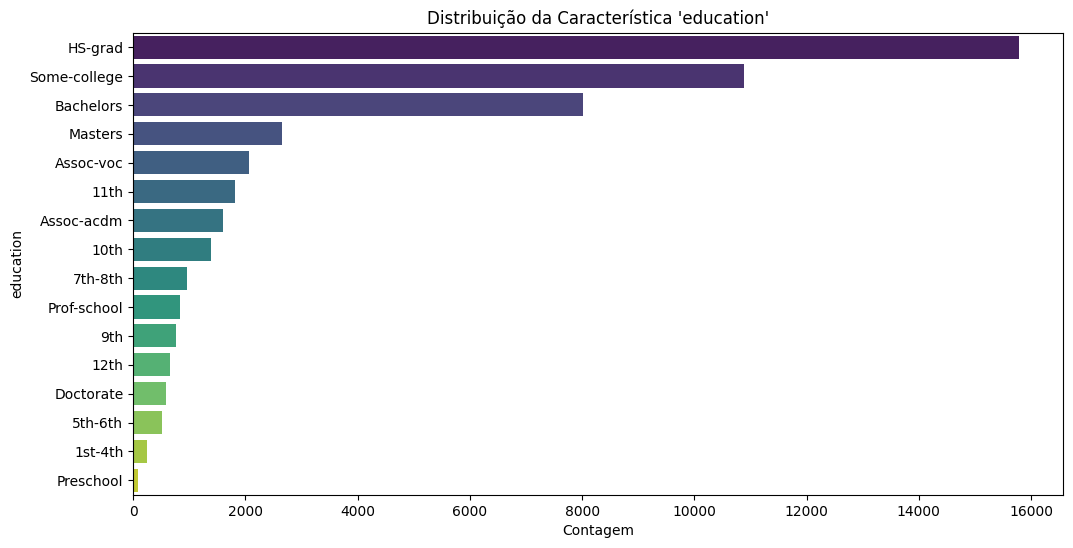

In [14]:


feature_name = 'education'


frequency_table = df[feature_name].value_counts()
print(f"Tabela de Frequência para a característica '{feature_name}':")
print(frequency_table)
print("\n")


plt.figure(figsize=(12, 6))
sns.countplot(data=df, y=feature_name, order=frequency_table.index, palette='viridis', legend=False)
plt.title(f"Distribuição da Característica '{feature_name}'")
plt.xlabel("Contagem")
plt.ylabel(feature_name)
plt.show()

### <font color='cyan'> Q11: Escolha uma característica numérica do conjunto de dados. Escreva seu nome a seguir.</font>

capital-gain

### <font color='cyan'> Q13: Crie e exiba um Histograma e/ou uma Estimativa de Densidade por Kernel (KDE) para a característica escolhida.</font>

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

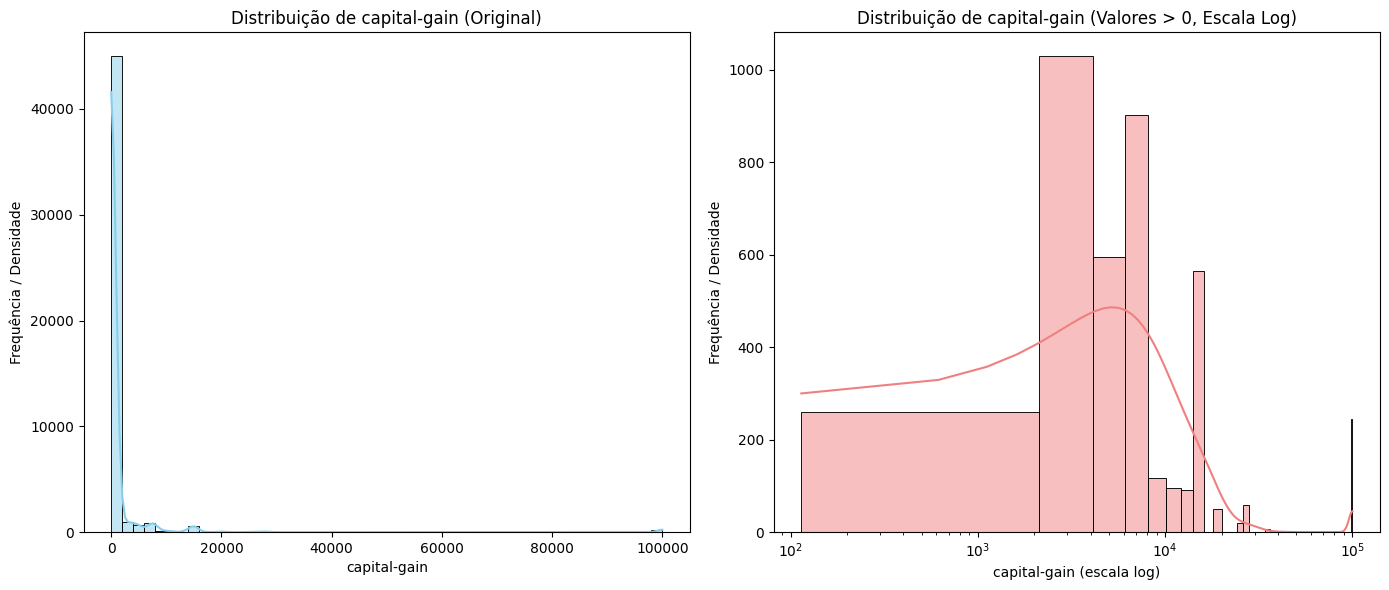

In [22]:


feature_name = 'capital-gain'

plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
sns.histplot(df[feature_name], kde=True, bins=50, color='skyblue')
plt.title(f'Distribuição de {feature_name} (Original)')
plt.xlabel(feature_name)
plt.ylabel('Frequência / Densidade')

capital_gain_nonzero = df[df[feature_name] > 0][feature_name]

plt.subplot(1, 2, 2)
if not capital_gain_nonzero.empty:
    sns.histplot(capital_gain_nonzero, kde=True, bins=50, color='lightcoral')
    plt.xscale('log')
    plt.title(f'Distribuição de {feature_name} (Valores > 0, Escala Log)')
    plt.xlabel(f'{feature_name} (escala log)')
    plt.ylabel('Frequência / Densidade')
else:
    plt.text(0.5, 0.5, 'Nenhum valor > 0 encontrado', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.title(f'Distribuição de {feature_name} (Valores > 0)')

plt.tight_layout()
plt.show()

## <font color='green'>**2.4 Análise Bivariada**</font>

### <font color='cyan'> Q14: Escolha duas características do conjuntos de dados. Escreva seus nome a seguir.</font>

native-country e income

### <font color='cyan'> Q15: De acordo com os tipos das características escolhidas, produza pelo menos uma visualização de análise bivariada.</font>

<Figure size 1500x800 with 0 Axes>

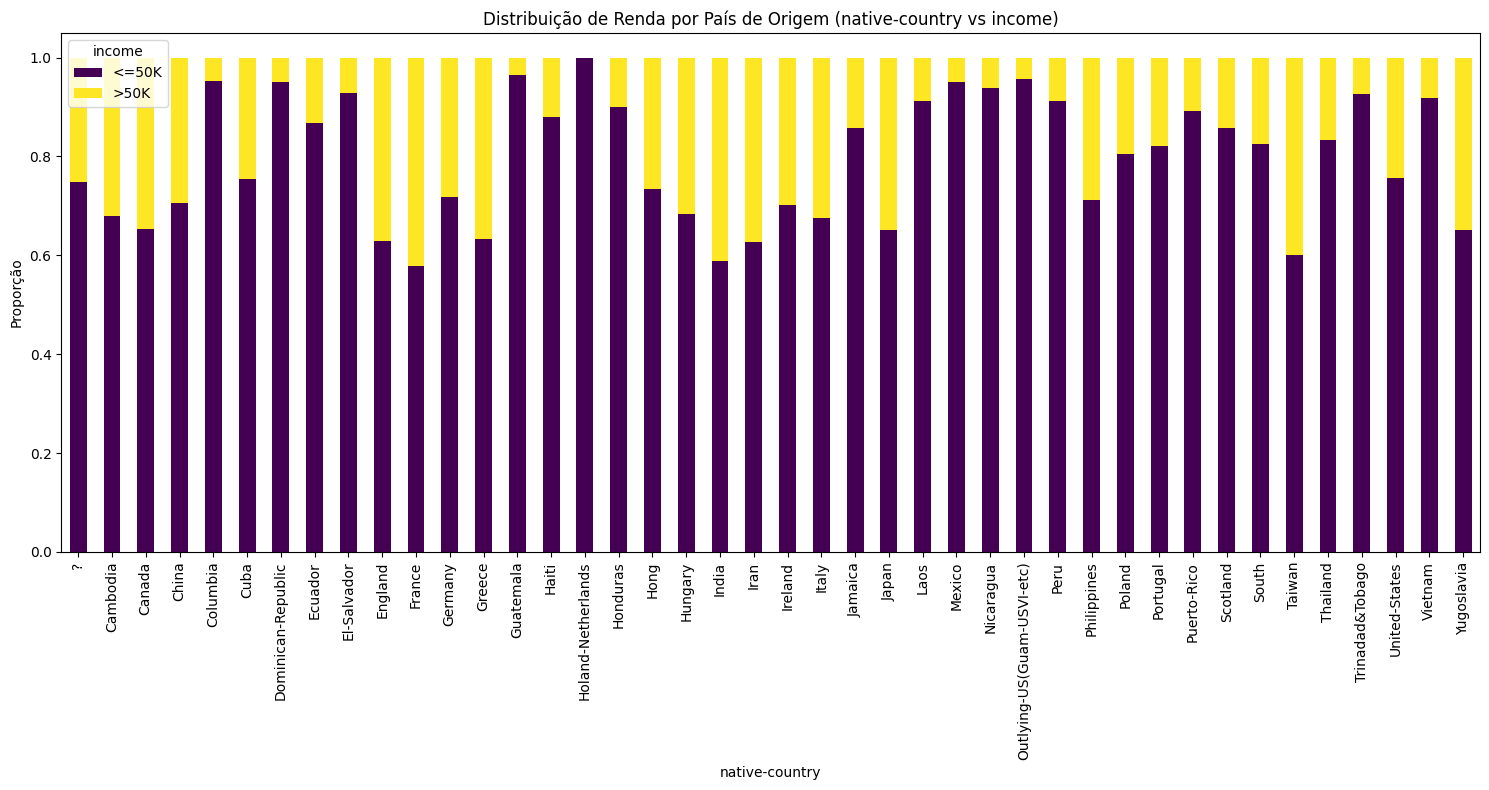

In [23]:

feature1 = 'native-country'
feature2 = 'income'


df[feature2] = df[feature2].replace({'<=50K.': '<=50K', '>50K.': '>50K'})


contingency_table = pd.crosstab(df[feature1], df[feature2])


proportions = contingency_table.div(contingency_table.sum(1).astype(float), axis=0)


plt.figure(figsize=(15, 8))
proportions.plot(kind='bar', stacked=True, figsize=(15, 8), cmap='viridis')
plt.title(f'Distribuição de Renda por País de Origem ({feature1} vs {feature2})')
plt.xlabel(feature1)
plt.ylabel('Proporção')
plt.xticks(rotation=90)
plt.legend(title=feature2)
plt.tight_layout()
plt.show()


## <font color='green'>**2.5 Identificação de Problemas nos Dados**</font>

### <font color='cyan'> Q16: Inspecione o conjuntos de dados para verificar se há:</font>
- #### <font color='cyan'> Dados Ausentes;</font>
- #### <font color='cyan'> Valores Atípicos (via IQR);</font>
- #### <font color='cyan'> Valores Duplicados;</font>
### <font color='cyan'> Reporte sua(s) descoberta(s) a seguir.</font>

In [17]:
print("--- Relatório de Inspeção de Dados ---")


print("\n1. Dados Ausentes:")
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if missing_values.empty:
    print("  Nenhum dado ausente encontrado.")
else:
    print(missing_values)
    print(f"  Total de dados ausentes: {missing_values.sum()}")


print("\n2. Valores Duplicados:")
duplicate_rows_count = df.duplicated().sum()
if duplicate_rows_count == 0:
    print("  Nenhuma linha duplicada encontrada.")
else:
    print(f"  Número de linhas duplicadas: {duplicate_rows_count}")


print("\n3. Valores Atípicos (Outliers via IQR):")
numerical_cols = df.select_dtypes(include=['number']).columns
outliers_found = False
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    if not outliers.empty:
        print(f"  - Característica '{col}': {len(outliers)} outliers (Mín: {outliers.min():.2f}, Máx: {outliers.max():.2f})")
        outliers_found = True

if not outliers_found:
    print("  Nenhum outlier significativo encontrado nas características numéricas.")

print("\n--- Fim do Relatório --- ")

--- Relatório de Inspeção de Dados ---

1. Dados Ausentes:
workclass         963
occupation        966
native-country    274
dtype: int64
  Total de dados ausentes: 2203

2. Valores Duplicados:
  Número de linhas duplicadas: 48

3. Valores Atípicos (Outliers via IQR):
  - Característica 'age': 216 outliers (Mín: 79.00, Máx: 90.00)
  - Característica 'fnlwgt': 1453 outliers (Mín: 417941.00, Máx: 1490400.00)
  - Característica 'education-num': 1794 outliers (Mín: 1.00, Máx: 4.00)
  - Característica 'capital-gain': 4035 outliers (Mín: 114.00, Máx: 99999.00)
  - Característica 'capital-loss': 2282 outliers (Mín: 155.00, Máx: 4356.00)
  - Característica 'hours-per-week': 13496 outliers (Mín: 1.00, Máx: 99.00)

--- Fim do Relatório --- 


### <font color='cyan'> Q17: Caso um problema tenha sido encontrado, proponha uma solução para ele.</font>
### <font color='cyan'> Exiba o conjunto de dados antes e depois da solução, enfatizando as mudanças.</font>

In [18]:
print("--- Conjunto de Dados ANTES da Solução ---")
print(f"Shape original: {df.shape}")
print("Valores ausentes originais:\n", df.isnull().sum()[df.isnull().sum() > 0])
print(f"Linhas duplicadas originais: {df.duplicated().sum()}\n")


df_cleaned = df.drop_duplicates().copy()


missing_categorical_cols = ['workclass', 'occupation', 'native-country']
for col in missing_categorical_cols:
    mode_value = df_cleaned[col].mode()[0]
    df_cleaned[col].fillna(mode_value, inplace=True)

print("--- Conjunto de Dados DEPOIS da Solução ---")
print(f"Novo shape: {df_cleaned.shape}")
print("Valores ausentes após a limpeza:\n", df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])
print(f"Linhas duplicadas após a limpeza: {df_cleaned.duplicated().sum()}\n")


df = df_cleaned.copy()

print("Primeiras 5 linhas do conjunto de dados após a limpeza:")
print(df.head())

--- Conjunto de Dados ANTES da Solução ---
Shape original: (48842, 15)
Valores ausentes originais:
 workclass         963
occupation        966
native-country    274
dtype: int64
Linhas duplicadas originais: 48



/tmp/ipykernel_1363/3114174321.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(mode_value, inplace=True)


--- Conjunto de Dados DEPOIS da Solução ---
Novo shape: (48794, 15)
Valores ausentes após a limpeza:
 Series([], dtype: int64)
Linhas duplicadas após a limpeza: 1

Primeiras 5 linhas do conjunto de dados após a limpeza:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specia

## <font color='green'>**2.6 Correlação Simples**</font>

### <font color='cyan'> Q18: Escolha duas características numéricas do conjuntos de dados. Escreva seus nomes a seguir.</font>

hours-per-week and age


### <font color='cyan'> Q19: Calcule e exiba o Coeficiente de Correlação de Pearson ($r$) entre elas.</font>

In [19]:
feature1 = 'hours-per-week'
feature2 = 'age'

pearson_corr = df[feature1].corr(df[feature2])

print(f"O Coeficiente de Correlação de Pearson entre '{feature1}' e '{feature2}' é: {pearson_corr:.2f}")

O Coeficiente de Correlação de Pearson entre 'hours-per-week' e 'age' é: 0.07


### <font color='cyan'> Q20: Interprete o coeficiente de correlação, em termos de sinal e magnitude.</font>


Pela maginitude estar proxima do 0 (0.07), isto significa que a força linear entre os dados é baixissima.

